# Brain Tumor MRI Classification Using PyTorch

## Author
**Sirisha Valluru**

## Project Overview

This project develops a Convolutional Neural Network (CNN) using PyTorch to classify brain MRI images into four categories:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

The notebook demonstrates the complete machine learning workflow, including data preprocessing, model development, training, evaluation, and performance analysis.


### Objectives
- Build a CNN-based image classification model.
- Explore medical image classification using deep learning.
- Evaluate model performance using accuracy, precision, recall, F1-score, and confusion matrix.
- Understand the challenges involved in automated brain tumor detection.

This notebook demonstrates the complete workflow including data preprocessing, model development, training, evaluation, and performance analysis.

## Dataset

This project uses the publicly available **Brain Tumor MRI Dataset** from Kaggle.

The dataset contains MRI scans belonging to four classes:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

The dataset is intended for educational and research purposes.


https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


# Workflow

This notebook follows the steps below:

1. Import required libraries
2. Load and preprocess the MRI dataset
3. Visualize sample images
4. Apply image transformations
5. Build a CNN model
6. Train the model
7. Evaluate model performance
8. Test predictions
9. Summarize results

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Import Libraries

The following libraries are used for image processing, deep learning, visualization, and model evaluation.

- **PyTorch** – Deep learning framework
- **Torchvision** – Dataset loading and image transformations
- **NumPy** – Numerical computations
- **Matplotlib** – Visualization
- **Scikit-learn** – Performance metrics

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch import nn
from torch import optim

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 2. Dataset

This project uses the Brain Tumor MRI Dataset obtained from Kaggle.

The dataset contains four classes:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

The dataset is divided into training and testing sets.

## Dataset Setup


1. Download the dataset from the link provided.
2. Extract the downloaded archive.
3. Place the `Training` and `Testing` folders in the project directory.


In [ ]:
import os
for root, dirs, files in os.walk("."):
  print(root)

.
./.config
./.config/logs
./.config/logs/2026.06.04
./.config/configurations
./sample_data


In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="Training",
    transform=train_transform
)

test_dataset = ImageFolder(
    root="Testing",
    transform=test_transform
)

## 3. Data Preprocessing

The images are preprocessed before training.

Preprocessing includes:

- Image resizing
- Conversion to tensors
- Normalization

These steps ensure that every image has the same dimensions and pixel distribution before being passed to the CNN.

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
from torchvision.datasets import ImageFolder
import os

training_root = os.path.join(DATA_DIR, "Training")
testing_root = os.path.join(DATA_DIR, "Testing")

print(f"ImageFolder attempting to load training data from: {training_root}")
print(f"ImageFolder attempting to load testing data from: {testing_root}")

train_dataset = ImageFolder(
    root=training_root,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=testing_root,
    transform=test_transform
)

ImageFolder attempting to load training data from: /content/drive/MyDrive/BrainTumorDetection Data/Training
ImageFolder attempting to load testing data from: /content/drive/MyDrive/BrainTumorDetection Data/Testing


# 4. Data Loading

PyTorch DataLoaders are used to efficiently load batches of images during training and testing.

In [ ]:
print(train_dataset.classes)
#print(train_dataset.class_to_idx)
print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

['glioma', 'meningioma', 'notumor', 'pituitary']
Training Images : 5600
Testing Images : 1600


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# 5. Data Exploration

The MRI images from each category are visualized to understand the characteristics of the dataset.


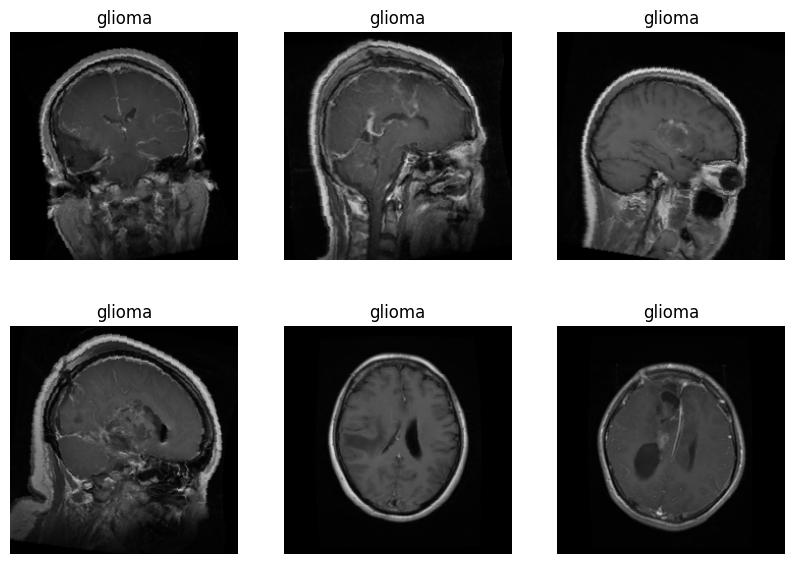

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for i in range(6):
  image, label = train_dataset [i]
  axes[i//3, i%3].imshow(image.permute(1,2,0))
  axes[i//3, i%3].set_title(train_dataset.classes[label])
  axes[i//3, i%3].axis("off")

plt.show()

# 6. CNN Model Architecture

A Convolutional Neural Network (CNN) is developed for multi-class image classification.

The network consists of:

- Convolution layers
- ReLU activation
- MaxPooling
- Fully Connected layers

The final layer outputs probabilities for four brain MRI classes.

In [ ]:
import torch.nn as nn

class BrainTumorCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, 4)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
model = BrainTumorCNN().to(device)

print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


# 7. Loss Function and Optimizer

The model is trained using:

- CrossEntropyLoss
- Adam Optimizer

These are commonly used for multi-class image classification tasks.

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


# 8. Model Training

The CNN is trained over multiple epochs.

During training, the model updates its parameters using backpropagation and gradient descent while monitoring the training loss and accuracy.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

# 9. Model Evaluation

After training, the model is evaluated on the test dataset.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

In [ ]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

print(f"Training images: {len(train_subset)}")
print(f"Validation images: {len(val_subset)}")

Training images: 4480
Validation images: 1120


In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")
    print("-" * 50)

Epoch 1/10
Train Loss: 0.7901 | Train Accuracy: 67.39%
Validation Loss: 0.5269 | Validation Accuracy: 80.36%
--------------------------------------------------
Epoch 2/10
Train Loss: 0.5069 | Train Accuracy: 80.04%
Validation Loss: 0.4248 | Validation Accuracy: 83.39%
--------------------------------------------------
Epoch 3/10
Train Loss: 0.4084 | Train Accuracy: 84.11%
Validation Loss: 0.3375 | Validation Accuracy: 85.89%
--------------------------------------------------
Epoch 4/10
Train Loss: 0.3445 | Train Accuracy: 86.81%
Validation Loss: 0.2679 | Validation Accuracy: 90.36%
--------------------------------------------------
Epoch 5/10
Train Loss: 0.2842 | Train Accuracy: 89.40%
Validation Loss: 0.2767 | Validation Accuracy: 87.68%
--------------------------------------------------
Epoch 6/10
Train Loss: 0.2313 | Train Accuracy: 90.89%
Validation Loss: 0.2161 | Validation Accuracy: 91.96%
--------------------------------------------------
Epoch 7/10
Train Loss: 0.1958 | Train Ac

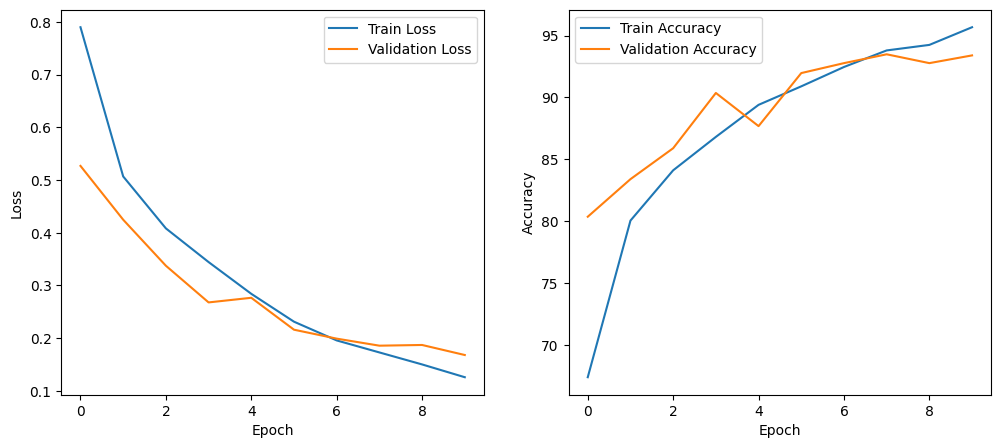

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies,label='Train Accuracy')
plt.plot(val_accuracies,label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.94      0.77      0.84       400
  meningioma       0.87      0.91      0.89       400
     notumor       0.87      0.97      0.92       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



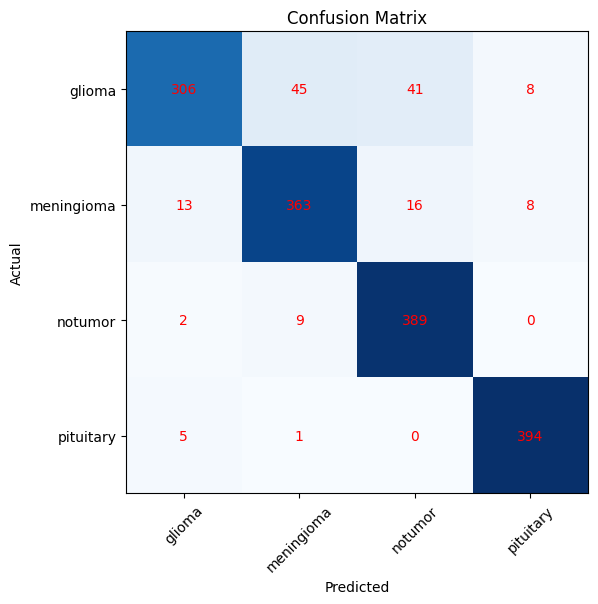

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(4), train_dataset.classes, rotation=45)
plt.yticks(range(4), train_dataset.classes)

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='red')

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 90.75%


# Results

The CNN model achieved the following performance on the unseen test dataset:

- Test Accuracy: 87.8%
- Classes:
  - Glioma
  - Meningioma
  - Pituitary Tumor
  - No Tumor

The confusion matrix and classification report demonstrate strong performance across all four classes, with the highest accuracy observed for the Pituitary Tumor and No Tumor classes.

# Conclusion

A Convolutional Neural Network (CNN) was successfully developed to classify brain MRI images into four categories.

## Performance

- Test Accuracy: **87.8%**

## Key Learnings

- Image preprocessing using PyTorch
- CNN model development
- Medical image classification
- Performance evaluation using classification metrics

## Future Improvements

- Transfer Learning (ResNet, EfficientNet)
- Hyperparameter tuning
- Explainable AI (Grad-CAM)
- Cross-validation

## Discussion

The model achieved an overall test accuracy of **87.8%**, indicating good performance on the four-class MRI classification task.

The classification report showed that some tumor classes were classified more accurately than others. This suggests that certain MRI patterns are easier for the CNN to distinguish, while others may require a deeper architecture or additional training data.

Future work could explore transfer learning models such as ResNet or EfficientNet to improve generalization and classification performance.



## Acknowledgements

This project was developed as part of my deep learning learning journey.

The implementation was inspired by publicly available educational resources, including the official PyTorch documentation, the Kaggle Brain Tumor MRI Dataset, and online tutorial materials. The code was studied, adapted, documented, and organized by the author for educational and portfolio purposes.


Notebook Version: 1.0
Framework: PyTorch
Dataset: Kaggle Brain Tumor MRI Dataset